# DATA EXPLORATION

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import neurokit2 as nk

from pathlib import Path
from tqdm import tqdm

plt.style.use("default")
pd.set_option("display.max_columns", None)

Dataset

In [8]:
dataset = Path("..\\01_dataset\\afdb")
hea_files = list(dataset.glob("*.hea"))
records = sorted([f.stem for f in hea_files])

print("Total record:", len(records))
print(records)

Total record: 23
['04015', '04043', '04048', '04126', '04746', '04908', '04936', '05091', '05121', '05261', '06426', '06453', '06995', '07162', '07859', '07879', '07910', '08215', '08219', '08378', '08405', '08434', '08455']


In [53]:
summary = []

for r in records:

    header = wfdb.rdheader(dataset / r)
    
    fs = header.fs
    total_samples = header.sig_len
    channels = header.sig_name
    
    duration_sec = total_samples / fs
    
    summary.append({
        "record": r,
        "sampling_rate": fs,
        "channels": ", ".join(channels),
        "total_samples": total_samples,
        "duration_hours": duration_sec / 3600
    })

df_summary = pd.DataFrame(summary)
df_summary

,record,sampling_rate,channels,total_samples,duration_hours
0,04015,250,"ECG1, ECG2",9205760,10.228622
1,04043,250,"ECG1, ECG2",9205760,10.228622
2,04048,250,"ECG1, ECG2",9205760,10.228622
3,04126,250,"ECG1, ECG2",9205760,10.228622
4,04746,250,"ECG1, ECG2",9205760,10.228622
5,04908,250,"ECG1, ECG2",9205760,10.228622
6,04936,250,"ECG1, ECG2",9205760,10.228622
7,05091,250,"ECG1, ECG2",9205760,10.228622
8,05121,250,"ECG1, ECG2",9205760,10.228622
9,05261,250,"ECG1, ECG2",9205760,10.228622


Anotasi

In [26]:
record_labels = []

for r in records:
    
    ann = wfdb.rdann(str(dataset / r), "atr")
    
    labels = set([l.replace("(", "") for l in ann.aux_note])
    
    record_labels.append({
        "record": r,
        "labels": sorted(labels),
        "total_label": len(labels)
    })

df_record_labels = pd.DataFrame(record_labels)
df_record_labels

,record,labels,total_label
0,04015,"[AFIB, N]",2
1,04043,"[AFIB, AFL, N]",3
2,04048,"[AFIB, N]",2
3,04126,"[AFIB, N]",2
4,04746,"[AFIB, N]",2
5,04908,"[AFIB, AFL, N]",3
6,04936,"[AFIB, AFL, N]",3
7,05091,"[AFIB, N]",2
8,05121,"[AFIB, J, N]",3
9,05261,"[AFIB, N]",2


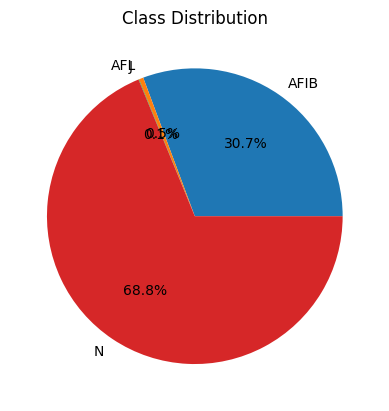

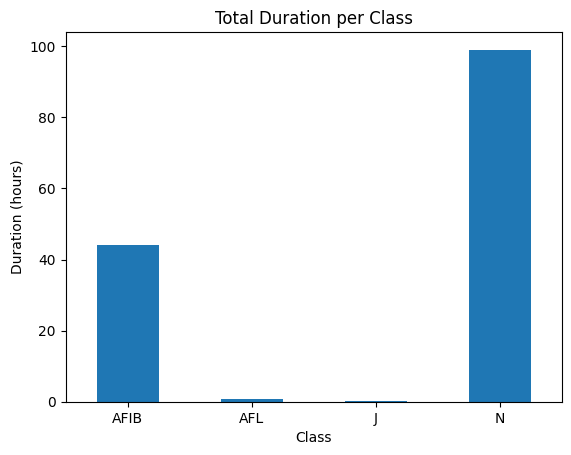

,Duration (hours),Percentage (%)
label,,
AFIB,44.16,30.67
AFL,0.69,0.48
J,0.09,0.06
N,99.03,68.78


In [52]:
fs = 250

duration_summary = []

for r in records:
    
    ann = wfdb.rdann(str(dataset / r), "atr")
    
    samples = ann.sample
    labels = [l.replace("(", "") for l in ann.aux_note]
    
    for i in range(len(samples)-1):
        
        start = samples[i]
        end = samples[i+1]
        
        duration_sec = (end - start) / fs
        
        duration_summary.append({
            "label": labels[i],
            "duration_second": duration_sec
        })

df_duration = pd.DataFrame(duration_summary)

duration_per_label = df_duration.groupby("label")["duration_second"].sum() / 3600

percentage_table = (duration_per_label / duration_per_label.sum()) * 100

summary_table = pd.DataFrame({
    "Duration (hours)": duration_per_label,
    "Percentage (%)": percentage_table
}).round(2)

plt.figure()

duration_per_label.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Class Distribution")
plt.ylabel("")
plt.show()

plt.figure()

duration_per_label.plot(
    kind="bar"
)

plt.title("Total Duration per Class")
plt.xlabel("Class")
plt.ylabel("Duration (hours)")
plt.xticks(rotation=0)
plt.show()

summary_table

In [56]:
fs = 250

record_label_summary = []

for r in records:
    
    ann = wfdb.rdann(str(dataset / r), "atr")
    record = wfdb.rdrecord(str(dataset / r))
    
    samples = ann.sample
    labels = [l.replace("(", "") for l in ann.aux_note]
    total_samples = record.sig_len
    
    durations = []

    for i in range(len(samples)-1):
        
        start = samples[i]
        end = samples[i+1]
        duration_sec = (end - start) / fs
        
        durations.append({
            "record": r,
            "label": labels[i],
            "duration_sec": duration_sec
        })
    
    last_start = samples[-1]
    last_label = labels[-1]
    duration_sec = (total_samples - last_start) / fs
    
    durations.append({
        "record": r,
        "label": last_label,
        "duration_sec": duration_sec
    })
    
    df_temp = pd.DataFrame(durations)
    total_duration = df_temp["duration_sec"].sum()
    
    percentage = (
        df_temp.groupby("label")["duration_sec"].sum() / total_duration
    ) * 100
    
    percentage = percentage.to_dict()
    percentage["record"] = r
    record_label_summary.append(percentage)

df_record_percentage = pd.DataFrame(record_label_summary).fillna(0)
cols = ["record"] + [c for c in df_record_percentage.columns if c != "record"]
df_record_percentage = df_record_percentage[cols]
df_record_percentage

,record,AFIB,N,AFL,J
0,04015,0.644262,99.355738,0.000000,0.000000
1,04043,21.507628,78.457339,0.035033,0.000000
2,04048,0.979775,99.020225,0.000000,0.000000
3,04126,3.742209,96.257791,0.000000,0.000000
4,04746,53.100286,46.899714,0.000000,0.000000
5,04908,8.371005,90.940251,0.688744,0.000000
6,04936,72.130973,18.660304,9.208722,0.000000
7,05091,0.235637,99.764363,0.000000,0.000000
8,05121,63.028513,36.347604,0.000000,0.623883
9,05261,1.302167,98.697833,0.000000,0.000000
